<a href="https://colab.research.google.com/github/bhoomijhamb56-gif/House-Price-Prediction/blob/main/Chitkara_IPM_Labs_15_18_ANN_Keras_Loan_Default_Prediction_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Labs 15–18: Artificial Neural Networks Using Keras  
## Loan Default Prediction for Credit Risk Management

### Complete Beginner-Friendly Deep Learning Pipeline

This notebook integrates the following laboratory topics:

- **Labs 15–16:** Introduction to Neural Networks using Keras and building a simple Artificial Neural Network (ANN)
- **Labs 17–18:** Training and testing Neural Network models, performance visualization using Matplotlib, and business interpretation of model outputs

### Business Domain
**Banking and Financial Services**

### Business Problem
A bank wants to identify loan applicants who are likely to default so that it can improve credit decisions, reduce Non-Performing Assets (NPAs), protect profitability, and maintain a healthy loan portfolio.

### Student Details

- **Name:** ______________________________
- **Roll Number:** _______________________
- **Section:** ____________________________
- **Date:** _______________________________

### Course
**Introduction to Artificial Intelligence and Machine Learning (25BBM2561)**  
**Integrated BBA (IPM) – Year IV**  
**Chitkara Business School**

# Understanding the Complete Deep Learning Pipeline

## What Is the Objective of This Lab?

The objective is to build an **Artificial Neural Network (ANN)** that predicts whether a loan applicant is likely to default.

The notebook has been designed for learners with **no prior coding background**. Each code cell performs one clear task and includes comments explaining what the code is doing.

## Complete Workflow

```text
Business Problem
        ↓
Understand Loan Default Risk
        ↓
Load the Dataset Automatically
        ↓
Explore and Clean the Data
        ↓
Separate Features and Target
        ↓
Encode Categorical Variables
        ↓
Scale Numerical Variables
        ↓
Create Training and Testing Data
        ↓
Build an Artificial Neural Network
        ↓
Compile and Train the Network
        ↓
Visualize Training and Validation Performance
        ↓
Test the Model
        ↓
Evaluate Accuracy, Precision, Recall and F1-score
        ↓
Study the Confusion Matrix
        ↓
Identify High-Risk Borrowers
        ↓
Business Interpretation
        ↓
Executive Summary and Recommendations
```

# Why This Lab Matters for Finance Students

Banks and lending institutions evaluate thousands of applications. A weak credit decision may lead to:

- Loan defaults
- Higher Non-Performing Assets
- Reduced profitability
- Increased recovery costs
- Liquidity pressure
- Regulatory and reputational risk

An ANN can learn complex relationships among income, credit score, debt burden, previous defaults, loan size, interest rate, and employment profile.

The model does **not** replace a credit manager. It supports the manager by providing an additional risk signal.

# Learning Outcomes

After completing this lab, students will be able to:

1. Explain an Artificial Neural Network in simple business language.
2. Identify the input, hidden, and output layers of an ANN.
3. Explain weights, bias, activation functions, epochs, batch size, loss, and optimizer.
4. Prepare financial data for a Neural Network.
5. Build a simple ANN using Keras.
6. Train and test the ANN.
7. Visualize training and validation accuracy and loss.
8. Evaluate the model using classification metrics.
9. Interpret the model from a credit-risk and managerial perspective.
10. Recommend responsible business actions based on model outputs.

# Part A: Neural Network Concepts Before Coding

## 1. What Is an Artificial Neural Network?

An Artificial Neural Network is a Machine Learning model inspired by the way biological neurons communicate.

In a loan decision, a credit manager may consider:

- Income
- Credit score
- Existing debt
- Employment stability
- Previous defaults
- Loan amount

An ANN also combines many inputs, learns their importance, and produces an output such as:

> **Estimated probability that the applicant will default**

The ANN learns from historical examples rather than being manually given every decision rule.

## 2. Structure of an ANN

```text
INPUT LAYER                 HIDDEN LAYERS                  OUTPUT LAYER

Annual Income  ─┐
Credit Score   ─┤
Loan Amount    ─┤        Artificial Neurons          Default Probability
Debt Ratio     ─┼──────► [ Hidden Layer 1 ] ──────►        0 to 1
Interest Rate ─┤        [ Hidden Layer 2 ]
Employment    ─┤
Past Default  ─┘
```

### Input Layer
Receives the applicant's financial information.

### Hidden Layers
Learn patterns and interactions among variables.

### Output Layer
Produces the final probability of default.

## 3. Important Neural Network Terms

| Term | Simple Meaning | Finance Analogy |
|---|---|---|
| Neuron | A small calculation unit | One credit analyst combining several signals |
| Weight | Importance assigned to an input | Credit score may receive more importance than age |
| Bias | Additional adjustable value | Baseline risk before considering applicant details |
| Activation Function | Decides how a neuron responds | Converts raw analysis into a useful risk signal |
| Epoch | One complete review of training data | Analyst reviews the entire historical portfolio once |
| Batch Size | Number of records processed together | Applications reviewed in small groups |
| Loss | Size of prediction error | Difference between expected and actual credit outcome |
| Optimizer | Method used to reduce errors | A learning strategy that improves future decisions |

## 4. Activation Functions Used in This Lab

### ReLU
Used in hidden layers. It helps the network learn complex patterns efficiently.

### Sigmoid
Used in the output layer for binary classification.

The Sigmoid output lies between 0 and 1:

- Value near **0** → lower estimated default risk
- Value near **1** → higher estimated default risk

## 5. Forward Propagation

Forward propagation means applicant information moves from the input layer through hidden layers to the output layer.

```text
Applicant Data → Hidden Calculations → Default Probability
```

For example:

```text
Income + Credit Score + Debt Ratio + Previous Default
                        ↓
              Artificial Neural Network
                        ↓
              Default Probability = 0.82
```

A probability of 0.82 means the model estimates an 82% chance of default under the patterns it learned.

## 6. Backpropagation

During training, the ANN compares its prediction with the actual outcome.

If the prediction is wrong:

1. The error is calculated.
2. The network sends correction information backward.
3. Weights and biases are adjusted.
4. The prediction process is repeated.

### Classroom Analogy

A student attempts a question, receives feedback, corrects the method, and improves. Backpropagation performs a similar learning process.

# Part B: Practical Implementation

## Step 1: Import the Required Libraries

A library contains ready-made tools.

- **Pandas** works with tables.
- **NumPy** performs numerical calculations.
- **Matplotlib** creates charts.
- **Scikit-learn** prepares and evaluates data.
- **TensorFlow/Keras** builds the Artificial Neural Network.

In [1]:
# Import standard libraries for data handling and visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import base64
from io import StringIO

# Import tools for preparing data and evaluating the model.
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# TensorFlow is already available in Google Colab.
# The following import gives access to Keras.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set random seeds so that results are reproducible.
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully.")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully.
TensorFlow version: 2.20.0


### Expected Output

You should see:

- `Libraries imported successfully.`
- The installed TensorFlow version

This confirms that the tools needed for the ANN are ready.

## Step 2: Load the Dataset Automatically

The complete loan dataset is embedded inside this notebook. No manual file upload is required.

In [2]:
# The dataset is stored as encoded text inside this notebook.
encoded_csv = """..."""

# Decode the text back into CSV format.
decoded_csv = base64.b64decode(encoded_csv).decode("utf-8")

# Read the CSV data into a Pandas DataFrame.
df = pd.read_csv(StringIO(decoded_csv))

print("Dataset loaded successfully.")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully.
Number of rows: 1208
Number of columns: 14


### Output Meaning

The dataset has loaded directly into the notebook. It includes a few missing values and duplicate rows so that students can practise realistic data cleaning.

## Step 3: Preview the Dataset

In [3]:
# Display the first five loan applications.
df.head()

,Applicant_ID,Age,Annual_Income_INR,Loan_Amount_INR,Credit_Score,Employment_Years,Debt_to_Income_Ratio,Existing_Loans,Previous_Defaults,Interest_Rate,Loan_Tenure_Months,Loan_Purpose,Employment_Type,Default
0,APP100001,25,1049426.0,613200,681.0,8.7,0.29,0,0,12.10,48,Business,Salaried,0
1,APP100002,55,629295.0,213571,644.0,0.0,0.30,2,0,5.64,60,Education,Self-Employed,0
2,APP100003,50,801767.0,988707,850.0,3.1,0.49,1,0,6.25,36,Vehicle,Salaried,0
3,APP100004,40,180000.0,792758,683.0,13.0,0.52,1,0,6.71,60,Personal,Unemployed,0
4,APP100005,40,376223.0,578632,806.0,7.4,0.24,2,0,10.60,60,Business,Self-Employed,0


### Business Interpretation

Each row represents one loan applicant. Each column provides a financial or applicant-related variable used in credit-risk assessment.

## Step 4: Understand the Dataset Columns

| Column | Business Meaning |
|---|---|
| Applicant_ID | Unique loan application identifier |
| Age | Applicant's age |
| Annual_Income_INR | Annual income in Indian Rupees |
| Loan_Amount_INR | Requested loan amount |
| Credit_Score | Indicator of creditworthiness |
| Employment_Years | Years of employment experience |
| Debt_to_Income_Ratio | Share of income used to service debt |
| Existing_Loans | Number of active loans |
| Previous_Defaults | Whether the applicant defaulted previously |
| Interest_Rate | Proposed loan interest rate |
| Loan_Tenure_Months | Loan repayment period |
| Loan_Purpose | Purpose of borrowing |
| Employment_Type | Applicant's employment category |
| Default | Target variable: 1 = Default, 0 = No Default |

## Step 5: Check the Shape and Data Types

In [4]:
# Display the size of the dataset.
print("Dataset shape:", df.shape)

# Display column names and data types.
df.info()

Dataset shape: (1208, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1208 entries, 0 to 1207
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Applicant_ID          1208 non-null   object 
 1   Age                   1208 non-null   int64  
 2   Annual_Income_INR     1196 non-null   float64
 3   Loan_Amount_INR       1208 non-null   int64  
 4   Credit_Score          1196 non-null   float64
 5   Employment_Years      1196 non-null   float64
 6   Debt_to_Income_Ratio  1208 non-null   float64
 7   Existing_Loans        1208 non-null   int64  
 8   Previous_Defaults     1208 non-null   int64  
 9   Interest_Rate         1208 non-null   float64
 10  Loan_Tenure_Months    1208 non-null   int64  
 11  Loan_Purpose          1208 non-null   object 
 12  Employment_Type       1208 non-null   object 
 13  Default               1208 non-null   int64  
dtypes: float64(5), int64(6), object(3)
memory usag

### Output Explanation

- `shape` tells us the number of rows and columns.
- `info()` helps identify numerical, categorical, and missing data.

## Step 6: Check Missing Values

In [5]:
# Count missing values in each column.
missing_values = df.isnull().sum()

# Show only columns that contain missing values.
missing_values[missing_values > 0]

,0
Annual_Income_INR,12
Credit_Score,12
Employment_Years,12


### Business Interpretation

Missing financial information can weaken credit decisions. Before training the ANN, missing values must be handled systematically.

## Step 7: Check Duplicate Records

In [6]:
# Count duplicate rows.
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 8


## Step 8: Remove Duplicate Records

In [7]:
# Remove exact duplicate rows.
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1200, 14)


### Output Meaning

Duplicate applications could incorrectly increase the influence of certain applicants. Removing them improves data quality.

## Step 9: Examine the Target Variable

In [8]:
# Count applicants who defaulted and did not default.
default_counts = df["Default"].value_counts().sort_index()

print("0 = No Default")
print("1 = Default")
print(default_counts)

0 = No Default
1 = Default
Default
0    944
1    256
Name: count, dtype: int64


## Step 10: Visualize Default Distribution

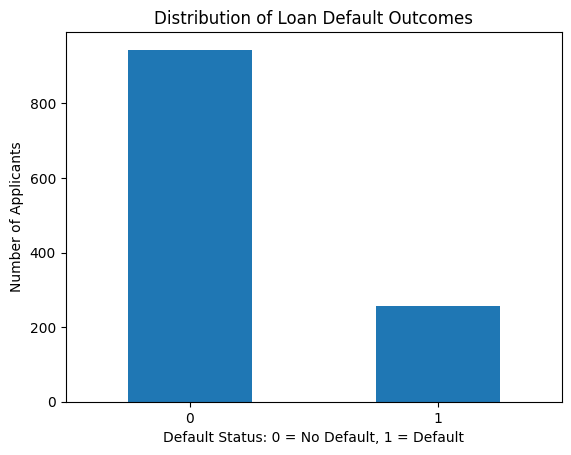

In [9]:
# Create a bar chart of the target classes.
default_counts.plot(kind="bar")

plt.title("Distribution of Loan Default Outcomes")
plt.xlabel("Default Status: 0 = No Default, 1 = Default")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.show()

### Business Interpretation

The chart shows how many applicants belong to each outcome group. Large class imbalance may cause a model to favour the majority class.

## Step 11: Explore Important Financial Variables

In [10]:
# Display descriptive statistics for selected financial variables.
financial_columns = [
    "Annual_Income_INR",
    "Loan_Amount_INR",
    "Credit_Score",
    "Debt_to_Income_Ratio",
    "Interest_Rate"
]

df[financial_columns].describe().round(2)

,Annual_Income_INR,Loan_Amount_INR,Credit_Score,Debt_to_Income_Ratio,Interest_Rate
count,1188.00,1200.00,1188.00,1200.00,1200.00
mean,688602.96,553158.76,690.11,0.35,11.49
std,275040.13,288046.51,71.25,0.15,3.88
min,180000.00,50000.00,484.00,0.03,5.00
25%,497054.25,344216.00,640.00,0.25,8.66
50%,693571.50,554091.00,689.00,0.34,11.32
75%,871709.50,749621.25,738.00,0.45,14.07
max,1590079.00,1467859.00,850.00,0.82,28.00


### Business Interpretation

Descriptive statistics help credit managers understand the applicant portfolio, typical borrowing levels, credit-score range, and debt burden.

## Step 12: Compare Credit Scores by Default Outcome

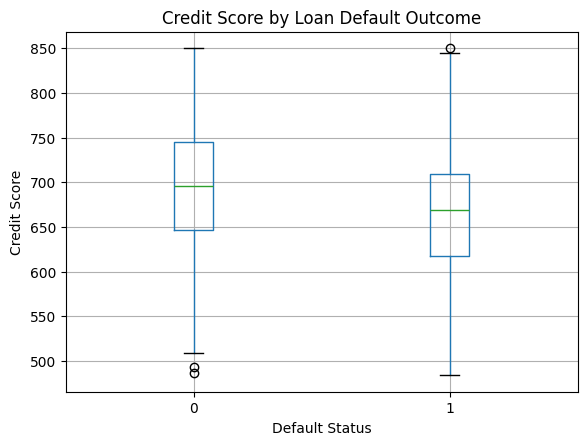

In [11]:
# Create a box plot using Pandas and Matplotlib.
df.boxplot(column="Credit_Score", by="Default")

plt.title("Credit Score by Loan Default Outcome")
plt.suptitle("")
plt.xlabel("Default Status")
plt.ylabel("Credit Score")
plt.show()

### Business Interpretation

Applicants who default often show different credit-score patterns. However, credit score alone is not sufficient; the ANN combines many variables.

## Step 13: Compare Debt-to-Income Ratio by Default Outcome

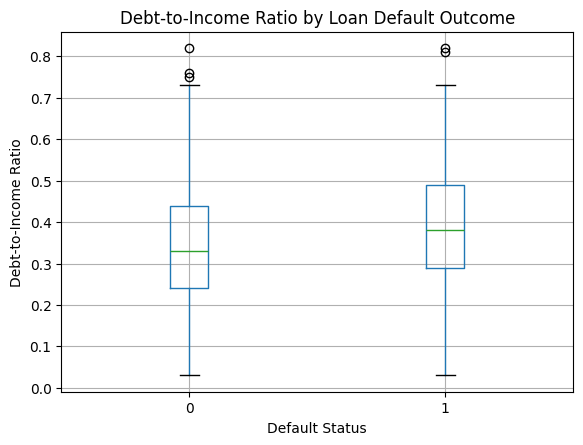

In [12]:
df.boxplot(column="Debt_to_Income_Ratio", by="Default")

plt.title("Debt-to-Income Ratio by Loan Default Outcome")
plt.suptitle("")
plt.xlabel("Default Status")
plt.ylabel("Debt-to-Income Ratio")
plt.show()

### Business Interpretation

A higher debt-to-income ratio may indicate repayment pressure. This variable is especially important in credit-risk assessment.

# Part C: Prepare Data for the ANN

## Step 14: Separate Features and Target

The target is `Default`.

`Applicant_ID` is removed because it is only an identifier and should not influence predictions.

In [13]:
# X contains input variables.
X = df.drop(columns=["Applicant_ID", "Default"])

# y contains the target variable.
y = df["Default"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (1200, 12)
Target vector shape: (1200,)


## Step 15: Identify Numerical and Categorical Columns

In [14]:
# Automatically identify numerical columns.
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Automatically identify categorical columns.
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Age', 'Annual_Income_INR', 'Loan_Amount_INR', 'Credit_Score', 'Employment_Years', 'Debt_to_Income_Ratio', 'Existing_Loans', 'Previous_Defaults', 'Interest_Rate', 'Loan_Tenure_Months']

Categorical columns:
['Loan_Purpose', 'Employment_Type']


## Step 16: Split the Dataset

- **Training data** teaches the ANN.
- **Testing data** checks performance on unseen applicants.

In [15]:
# Use 80% of the data for training and 20% for testing.
# stratify=y keeps a similar default distribution in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 960
Testing records: 240


## Step 17: Create the Preprocessing Pipeline

The pipeline will:

1. Fill missing numerical values using the median.
2. Scale numerical values.
3. Fill missing categorical values using the most frequent category.
4. Convert categorical variables into numbers using One-Hot Encoding.

In [16]:
# Pipeline for numerical variables.
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Pipeline for categorical variables.
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

# Combine both pipelines.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_columns),
        ("cat", categorical_pipeline, categorical_columns)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Step 18: Fit and Transform the Data

In [17]:
# Learn preprocessing rules from the training data.
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the same rules to the testing data.
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (960, 19)
Processed testing shape: (240, 19)


### Why Scaling Is Important for Neural Networks

Neural Networks train more effectively when numerical inputs are on comparable scales.

For example:

- Income may be measured in lakhs.
- Debt ratio may lie between 0 and 1.
- Credit score may lie between 300 and 850.

Scaling prevents large numerical values from dominating the learning process.

# Part D: Build the Artificial Neural Network Using Keras

## Step 19: Understand the Architecture

We will build:

- One input layer
- Two hidden layers
- One output layer

```text
Processed Financial Inputs
          ↓
Dense Layer: 32 neurons + ReLU
          ↓
Dense Layer: 16 neurons + ReLU
          ↓
Output Layer: 1 neuron + Sigmoid
          ↓
Probability of Default
```

In [18]:
# Find the number of processed input features.
number_of_input_features = X_train_processed.shape[1]

print("Number of ANN input features:", number_of_input_features)

Number of ANN input features: 19


## Step 20: Build the ANN Model

In [19]:
# Create a Sequential Neural Network.
model = keras.Sequential(
    [
        # Input layer tells Keras the number of input features.
        layers.Input(shape=(number_of_input_features,)),

        # First hidden layer with 32 neurons.
        layers.Dense(32, activation="relu"),

        # Second hidden layer with 16 neurons.
        layers.Dense(16, activation="relu"),

        # Output layer for binary classification.
        layers.Dense(1, activation="sigmoid")
    ],
    name="Loan_Default_ANN"
)

print("Artificial Neural Network created successfully.")

Artificial Neural Network created successfully.


## Step 21: View the Model Summary

In [20]:
# Display the architecture and number of trainable parameters.
model.summary()

Model: "Loan_Default_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185 (4.63 KB)

 Trainable params: 1,185 (4.63 KB)

 Non-trainable params: 0 (0.00 B)

### How to Read the Summary

- `Dense` indicates a fully connected layer.
- `Output Shape` shows the number of neurons.
- `Param #` shows the number of learnable weights and biases.
- The final layer has one neuron because this is a binary classification problem.

## Step 22: Compile the ANN

We must tell Keras:

- **Optimizer:** How the network should improve.
- **Loss Function:** How prediction error should be measured.
- **Metric:** What performance measure should be displayed.

In [21]:
# Compile the ANN.
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


### Why These Choices?

- **Adam** is a widely used optimizer that adjusts the model efficiently.
- **Binary cross-entropy** is suitable for two-class outcomes.
- **Accuracy** shows the proportion of correct predictions during training.

# Part E: Train the Neural Network

## Step 23: Train the ANN

Important settings:

- **Epochs = 30:** The model reviews the training data 30 times.
- **Batch Size = 32:** The model processes 32 records at a time.
- **Validation Split = 20%:** Part of the training data checks performance after each epoch.

In [22]:
# Train the model and store the training history.
history = model.fit(
    X_train_processed,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.5065 - loss: 0.7231 - val_accuracy: 0.7135 - val_loss: 0.6253
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7539 - loss: 0.5900 - val_accuracy: 0.7604 - val_loss: 0.5649
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7891 - loss: 0.5369 - val_accuracy: 0.7708 - val_loss: 0.5407
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7891 - loss: 0.5075 - val_accuracy: 0.7708 - val_loss: 0.5274
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7891 - loss: 0.4873 - val_accuracy: 0.7760 - val_loss: 0.5187
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7891 - loss: 0.4726 - val_accuracy: 0.7760 - val_loss: 0.5124
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7891 - loss: 0.4610 - val_accuracy: 0.7760 - val_loss: 0.5083
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7930 - loss: 0.4521 - val_accuracy: 0.7656 - va

### How to Read the Training Output

For each epoch, Keras displays:

- `loss`: Training error
- `accuracy`: Training accuracy
- `val_loss`: Validation error
- `val_accuracy`: Validation accuracy

A good model should improve on training data without showing a large and persistent gap from validation performance.

# Part F: Performance Visualization Using Matplotlib

## Step 24: Plot Training and Validation Accuracy

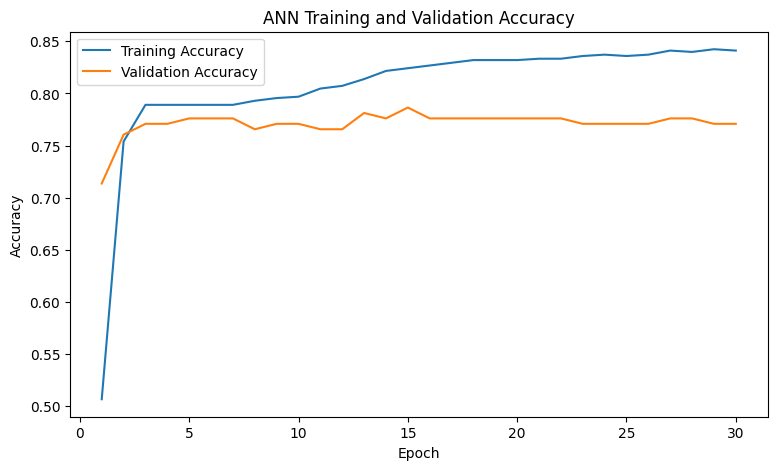

In [23]:
# Store values from the training history.
training_accuracy = history.history["accuracy"]
validation_accuracy = history.history["val_accuracy"]

# Create epoch numbers for the x-axis.
epochs = range(1, len(training_accuracy) + 1)

# Plot accuracy.
plt.figure(figsize=(9, 5))
plt.plot(epochs, training_accuracy, label="Training Accuracy")
plt.plot(epochs, validation_accuracy, label="Validation Accuracy")

plt.title("ANN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Interpretation Guide

- Rising training and validation accuracy indicates learning.
- Similar curves indicate reasonable generalization.
- Very high training accuracy with much lower validation accuracy may indicate overfitting.

## Step 25: Plot Training and Validation Loss

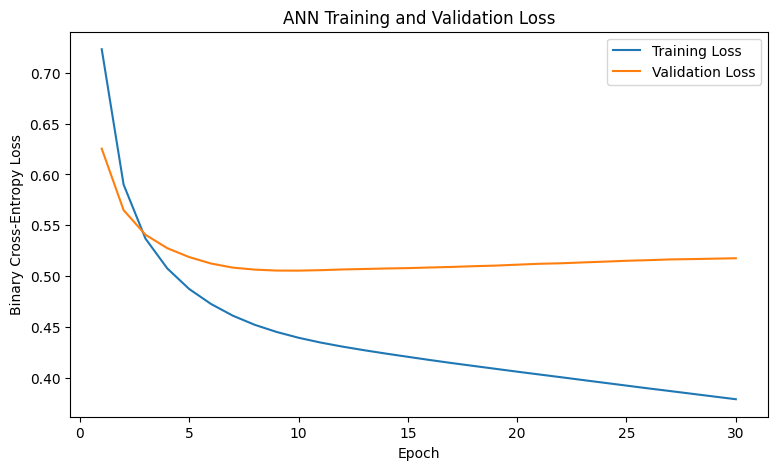

In [24]:
# Store loss values.
training_loss = history.history["loss"]
validation_loss = history.history["val_loss"]

# Plot loss.
plt.figure(figsize=(9, 5))
plt.plot(epochs, training_loss, label="Training Loss")
plt.plot(epochs, validation_loss, label="Validation Loss")

plt.title("ANN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.show()

### Interpretation Guide

- Falling loss indicates that prediction errors are decreasing.
- Validation loss that begins rising while training loss continues falling may indicate overfitting.

# Part G: Test the ANN on Unseen Data

## Step 26: Evaluate the Model

In [25]:
# Evaluate the model on unseen testing data.
test_loss, test_accuracy = model.evaluate(
    X_test_processed,
    y_test,
    verbose=0
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

Test Loss: 0.4572
Test Accuracy: 0.7917


### Business Interpretation

Test accuracy estimates how often the model correctly classifies unseen loan applicants. It should never be interpreted alone because default detection may require special attention to recall and false negatives.

## Step 27: Generate Default Probabilities

In [26]:
# Predict the probability of default for each testing applicant.
default_probabilities = model.predict(X_test_processed, verbose=0).ravel()

# Display the first ten probabilities.
print(default_probabilities[:10])

[0.06425726 0.09037347 0.17935686 0.03612749 0.06307974 0.54007906
 0.38215607 0.15521704 0.09485554 0.0701065 ]


### Output Meaning

Each number lies between 0 and 1.

Example:

- `0.08` → approximately 8% estimated default probability
- `0.82` → approximately 82% estimated default probability

## Step 28: Convert Probabilities into Class Predictions

We will use a threshold of 0.50:

- Probability below 0.50 → Predict No Default
- Probability 0.50 or above → Predict Default

In [27]:
# Convert probabilities into class predictions.
y_pred = (default_probabilities >= 0.50).astype(int)

print("First ten predicted classes:")
print(y_pred[:10])

First ten predicted classes:
[0 0 0 0 0 1 0 0 0 0]


## Step 29: Calculate Classification Metrics

In [28]:
# Calculate important classification metrics.
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

metrics_table = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Score": [accuracy, precision, recall, f1]
    }
)

metrics_table["Score"] = metrics_table["Score"].round(4)
metrics_table

,Metric,Score
0,Accuracy,0.7917
1,Precision,0.5294
2,Recall,0.1765
3,F1-score,0.2647


## Step 30: Interpret the Metrics

| Metric | Credit-Risk Meaning |
|---|---|
| Accuracy | Overall proportion of correct decisions |
| Precision | Among applicants predicted to default, how many actually defaulted |
| Recall | Among actual defaulters, how many the model identified |
| F1-score | Balance between precision and recall |

### Why Recall Matters

A **false negative** means an actual defaulter was predicted as safe. This can expose the bank to financial loss.

However, using very high recall without considering precision may reject too many reliable applicants. The threshold must therefore reflect the bank's risk appetite.

## Step 31: Display the Classification Report

In [29]:
# Display a detailed classification report.
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Default", "Default"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  No Default       0.81      0.96      0.88       189
     Default       0.53      0.18      0.26        51

    accuracy                           0.79       240
   macro avg       0.67      0.57      0.57       240
weighted avg       0.75      0.79      0.75       240



## Step 32: Create the Confusion Matrix

In [30]:
# Calculate the confusion matrix.
cm = confusion_matrix(y_test, y_pred)

# Convert it into a labelled table.
confusion_table = pd.DataFrame(
    cm,
    index=["Actual No Default", "Actual Default"],
    columns=["Predicted No Default", "Predicted Default"]
)

confusion_table

,Predicted No Default,Predicted Default
Actual No Default,181,8
Actual Default,42,9


## Step 33: Visualize the Confusion Matrix

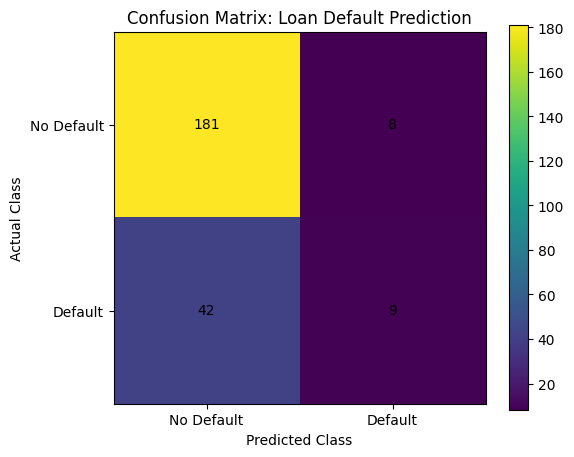

In [31]:
# Display the confusion matrix using Matplotlib.
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix: Loan Default Prediction")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks([0, 1], ["No Default", "Default"])
plt.yticks([0, 1], ["No Default", "Default"])

# Write each value inside its square.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

## Step 34: Understand TP, TN, FP and FN

In [32]:
# Extract values from the confusion matrix.
tn, fp, fn, tp = cm.ravel()

confusion_summary = pd.DataFrame(
    {
        "Category": [
            "True Negative",
            "False Positive",
            "False Negative",
            "True Positive"
        ],
        "Count": [tn, fp, fn, tp],
        "Business Meaning": [
            "Safe applicant correctly identified",
            "Safe applicant incorrectly flagged as risky",
            "Actual defaulter incorrectly treated as safe",
            "Actual defaulter correctly identified"
        ]
    }
)

confusion_summary

,Category,Count,Business Meaning
0,True Negative,181,Safe applicant correctly identified
1,False Positive,8,Safe applicant incorrectly flagged as risky
2,False Negative,42,Actual defaulter incorrectly treated as safe
3,True Positive,9,Actual defaulter correctly identified


### Credit-Risk Interpretation

- **True Negative:** Correct approval or lower-risk treatment.
- **False Positive:** A reliable applicant may face unnecessary rejection or review.
- **False Negative:** A risky applicant may receive a loan and later default.
- **True Positive:** A risky applicant is correctly identified for rejection or enhanced review.

# Part H: Build an Executive Risk Table

## Step 35: Combine Applicants with Predicted Probabilities

In [33]:
# Create a copy of the original testing records.
risk_results = X_test.copy()

# Add actual outcome, predicted outcome, and predicted probability.
risk_results["Actual_Default"] = y_test.values
risk_results["Predicted_Default"] = y_pred
risk_results["Default_Probability"] = default_probabilities

# Add Applicant ID from the original dataframe using matching indices.
risk_results["Applicant_ID"] = df.loc[X_test.index, "Applicant_ID"].values

# Arrange important columns first.
risk_results = risk_results[
    [
        "Applicant_ID",
        "Annual_Income_INR",
        "Loan_Amount_INR",
        "Credit_Score",
        "Debt_to_Income_Ratio",
        "Previous_Defaults",
        "Employment_Type",
        "Loan_Purpose",
        "Default_Probability",
        "Predicted_Default",
        "Actual_Default"
    ]
]

risk_results.head()

,Applicant_ID,Annual_Income_INR,Loan_Amount_INR,Credit_Score,Debt_to_Income_Ratio,Previous_Defaults,Employment_Type,Loan_Purpose,Default_Probability,Predicted_Default,Actual_Default
604,APP100605,939312.0,787102,844.0,0.56,0,Salaried,Education,0.064257,0,0
766,APP100767,552520.0,786245,737.0,0.33,0,Self-Employed,Home,0.090373,0,0
599,APP100600,486647.0,701333,715.0,0.28,0,Salaried,Education,0.179357,0,0
969,APP100970,201393.0,863816,788.0,0.39,0,Salaried,Education,0.036127,0,0
1029,APP101030,842262.0,1067840,666.0,0.27,0,Self-Employed,Vehicle,0.063080,0,0


## Step 36: Create Risk Categories

This is a managerial classification for decision support:

- **Low Risk:** Probability below 30%
- **Moderate Risk:** Probability from 30% to below 60%
- **High Risk:** Probability 60% or above

These thresholds are illustrative and should be validated against business policy.

In [34]:
# Convert probability into business-friendly risk categories.
risk_results["Risk_Category"] = pd.cut(
    risk_results["Default_Probability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Moderate Risk", "High Risk"]
)

risk_results.head()

,Applicant_ID,Annual_Income_INR,Loan_Amount_INR,Credit_Score,Debt_to_Income_Ratio,Previous_Defaults,Employment_Type,Loan_Purpose,Default_Probability,Predicted_Default,Actual_Default,Risk_Category
604,APP100605,939312.0,787102,844.0,0.56,0,Salaried,Education,0.064257,0,0,Low Risk
766,APP100767,552520.0,786245,737.0,0.33,0,Self-Employed,Home,0.090373,0,0,Low Risk
599,APP100600,486647.0,701333,715.0,0.28,0,Salaried,Education,0.179357,0,0,Low Risk
969,APP100970,201393.0,863816,788.0,0.39,0,Salaried,Education,0.036127,0,0,Low Risk
1029,APP101030,842262.0,1067840,666.0,0.27,0,Self-Employed,Vehicle,0.063080,0,0,Low Risk


## Step 37: View High-Risk Applicants

In [35]:
# Sort applicants from highest to lowest predicted risk.
high_risk_applicants = (
    risk_results[risk_results["Risk_Category"] == "High Risk"]
    .sort_values("Default_Probability", ascending=False)
)

# Display the ten highest-risk applicants.
high_risk_applicants.head(10)

,Applicant_ID,Annual_Income_INR,Loan_Amount_INR,Credit_Score,Debt_to_Income_Ratio,Previous_Defaults,Employment_Type,Loan_Purpose,Default_Probability,Predicted_Default,Actual_Default,Risk_Category
132,APP100133,881296.0,680638,629.0,0.40,1,Salaried,Vehicle,0.748350,1,1,High Risk
433,APP100434,354252.0,787118,525.0,0.62,0,Salaried,Home,0.739055,1,1,High Risk
838,APP100839,461396.0,346306,635.0,0.30,0,Salaried,Business,0.734877,1,0,High Risk
189,APP100190,723414.0,621517,624.0,0.54,1,Self-Employed,Education,0.722606,1,1,High Risk
978,APP100979,524056.0,190724,540.0,0.31,0,Salaried,Home,0.712875,1,0,High Risk
28,APP100029,851517.0,50000,655.0,0.51,1,Contract,Home,0.710092,1,1,High Risk
1090,APP101091,700560.0,1008794,684.0,0.36,0,Salaried,Personal,0.608817,1,1,High Risk


### Business Interpretation

High-risk applicants should not be automatically rejected solely because of the model.

They may be sent for:

- Detailed credit review
- Income verification
- Bank-statement analysis
- Collateral assessment
- Additional documentation
- Human credit committee review

## Step 38: Create a Risk Category Summary

In [36]:
# Count applicants in each risk category.
risk_category_summary = (
    risk_results["Risk_Category"]
    .value_counts()
    .reindex(["Low Risk", "Moderate Risk", "High Risk"])
)

risk_category_summary

,count
Risk_Category,
Low Risk,196
Moderate Risk,37
High Risk,7


## Step 39: Visualize the Risk Portfolio

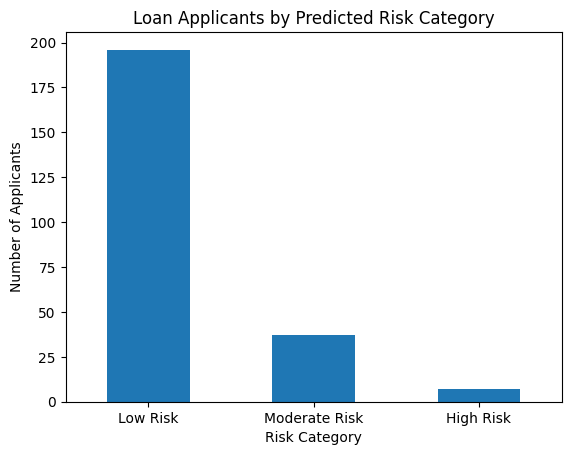

In [37]:
risk_category_summary.plot(kind="bar")

plt.title("Loan Applicants by Predicted Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.show()

# Part I: Make a Prediction for a New Loan Applicant

The following example demonstrates how the ANN may support a new credit decision.

In [38]:
# Create one new loan applicant.
new_applicant = pd.DataFrame(
    {
        "Age": [34],
        "Annual_Income_INR": [650000],
        "Loan_Amount_INR": [900000],
        "Credit_Score": [610],
        "Employment_Years": [4],
        "Debt_to_Income_Ratio": [0.58],
        "Existing_Loans": [3],
        "Previous_Defaults": [1],
        "Interest_Rate": [16.5],
        "Loan_Tenure_Months": [60],
        "Loan_Purpose": ["Business"],
        "Employment_Type": ["Self-Employed"]
    }
)

new_applicant

,Age,Annual_Income_INR,Loan_Amount_INR,Credit_Score,Employment_Years,Debt_to_Income_Ratio,Existing_Loans,Previous_Defaults,Interest_Rate,Loan_Tenure_Months,Loan_Purpose,Employment_Type
0,34,650000,900000,610,4,0.58,3,1,16.5,60,Business,Self-Employed


## Step 40: Preprocess and Predict

In [39]:
# Apply the same preprocessing rules used for training.
new_applicant_processed = preprocessor.transform(new_applicant)

# Predict default probability.
new_default_probability = model.predict(
    new_applicant_processed,
    verbose=0
).ravel()[0]

print("Predicted Default Probability:", round(new_default_probability, 4))
print("Predicted Default Percentage:", round(new_default_probability * 100, 2), "%")

Predicted Default Probability: 0.8999
Predicted Default Percentage: 89.99 %


## Step 41: Convert the Prediction into a Managerial Decision Category

In [40]:
# Create a decision-support message.
if new_default_probability < 0.30:
    decision = "Low Risk: Continue with standard credit assessment."
elif new_default_probability < 0.60:
    decision = "Moderate Risk: Conduct additional verification and manual review."
else:
    decision = "High Risk: Escalate to senior credit review before approval."

print(decision)

High Risk: Escalate to senior credit review before approval.


### Important Governance Note

The ANN output is a **decision-support signal**, not a final legal or ethical decision.

A responsible bank should also consider:

- Verified documents
- Regulatory requirements
- Fair lending practices
- Human review
- Model bias
- Data privacy
- Explainability
- Customer grievance mechanisms

# Part J: Executive Business Dashboard Summary

In [41]:
# Create a compact executive summary.
executive_summary = pd.DataFrame(
    {
        "Business Indicator": [
            "Total Test Applications",
            "Predicted High-Risk Applicants",
            "Predicted Moderate-Risk Applicants",
            "Predicted Low-Risk Applicants",
            "Test Accuracy",
            "Precision for Default",
            "Recall for Default",
            "F1-score for Default"
        ],
        "Value": [
            len(risk_results),
            int((risk_results["Risk_Category"] == "High Risk").sum()),
            int((risk_results["Risk_Category"] == "Moderate Risk").sum()),
            int((risk_results["Risk_Category"] == "Low Risk").sum()),
            round(accuracy, 4),
            round(precision, 4),
            round(recall, 4),
            round(f1, 4)
        ]
    }
)

executive_summary

,Business Indicator,Value
0,Total Test Applications,240.0000
1,Predicted High-Risk Applicants,7.0000
2,Predicted Moderate-Risk Applicants,37.0000
3,Predicted Low-Risk Applicants,196.0000
4,Test Accuracy,0.7917
5,Precision for Default,0.5294
6,Recall for Default,0.1765
7,F1-score for Default,0.2647


# Key Business Insights

After running the notebook, students should complete the following statements using their outputs:

1. The ANN achieved a test accuracy of **__________**.
2. Recall for the default class was **__________**.
3. The number of false negatives was **__________**.
4. The number of applicants classified as high risk was **__________**.
5. The most important operational concern is **____________________________**.
6. A false negative is costly because **___________________________________**.

# Managerial Recommendations

A bank may use the model to:

1. Prioritize high-risk applications for enhanced due diligence.
2. Reduce avoidable loan defaults and recovery costs.
3. Improve the speed of first-level risk screening.
4. Allocate credit analysts to applications requiring deeper investigation.
5. Monitor the loan portfolio using probability-based risk bands.
6. Adjust decision thresholds according to risk appetite and product type.
7. Retrain the model when applicant behaviour or economic conditions change.
8. Audit the model for bias and unfair outcomes.
9. Keep a human credit manager in the final decision process.
10. Document model assumptions, limitations, and review procedures.

# Limitations of the Model

This educational model has several limitations:

- The dataset is synthetic and created for classroom learning.
- Real banks use more variables and stronger data validation.
- Economic conditions may change default behaviour.
- The ANN does not automatically explain every prediction.
- A threshold of 0.50 may not be optimal for every lending product.
- High accuracy does not guarantee fairness or compliance.
- Model outputs should not be used without human governance.

# ANN versus Traditional Machine Learning

| Area | Logistic Regression | Decision Tree | Artificial Neural Network |
|---|---|---|---|
| Interpretation | High | Moderate to high | Lower |
| Non-linear pattern learning | Limited | Good | Strong |
| Data requirement | Low to moderate | Low to moderate | Usually higher |
| Training complexity | Low | Low | Higher |
| Suitable for complex relationships | Limited | Moderate | Strong |
| Business use | Credit scoring baseline | Decision rules | Complex risk modelling |

A more complex model is not automatically a better model. Model selection should consider accuracy, interpretability, cost, fairness, and governance.

# Student Reflection Questions

Answer in your own words:

1. Why is loan default prediction a classification problem?
2. What does one neuron do?
3. Why is ReLU used in hidden layers?
4. Why is Sigmoid used in the output layer?
5. What is an epoch?
6. What is the difference between training and validation accuracy?
7. What does rising validation loss indicate?
8. Why can false negatives be expensive for a bank?
9. Why should an ANN not automatically reject applicants?
10. When might a simpler model be preferred over an ANN?

# Suggested Portfolio Description

## GitHub Project Title
**Loan Default Prediction Using an Artificial Neural Network**

## Resume Description
Built a Keras-based Artificial Neural Network to predict loan-default risk using financial and applicant variables. Performed data cleaning, preprocessing, categorical encoding, feature scaling, ANN training, performance visualization, classification evaluation, risk segmentation, and business interpretation for credit-risk decision support.

## Skills Demonstrated

- Python
- Pandas
- Matplotlib
- Scikit-learn
- TensorFlow
- Keras
- Artificial Neural Networks
- Classification Metrics
- Credit Risk Analytics
- Business Interpretation
- Responsible AI

# Final Conclusion

This lab demonstrated the complete use of an Artificial Neural Network for a finance-related business problem.

Students learned how to:

- Understand the loan-default problem
- Prepare financial data
- Build an ANN using Keras
- Train and test the network
- Visualize accuracy and loss
- Interpret classification metrics
- Identify high-risk applicants
- Convert model outputs into managerial recommendations
- Recognize governance, fairness, and ethical responsibilities

The most important lesson is:

> A Neural Network produces predictions, but business value is created only when predictions are interpreted responsibly and converted into appropriate managerial action.